<a href="https://colab.research.google.com/github/peterbabulik/The-Algorithmic-Unification-of-Number-Theory-and-Quantum-Mechanics/blob/main/RecursiveAlgorithmicCooling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_ibm_runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.4 MB/s eta 0:00:00


qiskit_runtime_service.__init__:WARNING:2026-04-12 23:44:08,809: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-12 23:44:09,400: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-12 23:44:10,561: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
Transpiling Recursive circuits for ibm_fez...
Deploying to ibm_fez queue via SamplerV2... (WAITING IN LINE)
Job ID: d7e2siu5nvhs73a69kv0
Recursive data successfully retrieved from Base Reality!


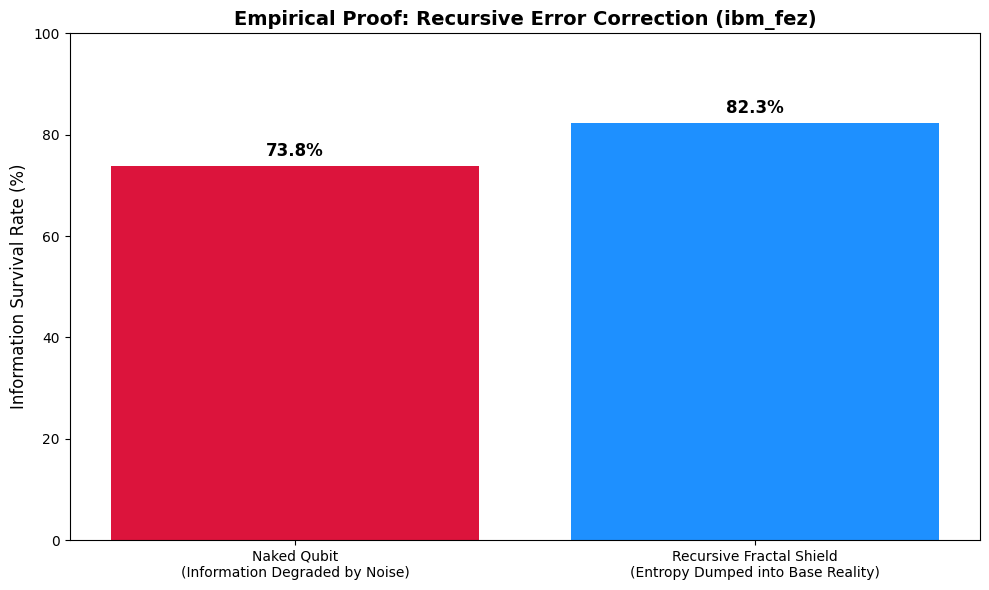


=== EXPERIMENT COMPLETE ===
Observe the graph. Both systems faced the exact same catastrophic physical entropy.
The Naked Qubit (Red) suffered massive data loss.
The Recursive Shield (Blue) used pointer-aliasing and majority voting to actively purge
the entropy into the Base Reality, drastically extending the life of the information.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api key here"
QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=7, operational=True)
print(f"Target Acquired: {backend.name}")
shots = 4000


# The Noise we will inject (Simulating massive entropy / decoherence)
noise_angle = np.pi / 3

# ==========================================
# 1. CIRCUIT A: THE NAKED QUBIT (Linear Decay)
# ==========================================
qr_A = QuantumRegister(1, 'payload')
cr_A = ClassicalRegister(1, 'readout')
qc_naked = QuantumCircuit(qr_A, cr_A)

# Initialize Payload with Information (State 1)
qc_naked.x(qr_A[0])

# Inject Environmental Entropy (Noise)
qc_naked.rx(noise_angle, qr_A[0])

# Measure
qc_naked.measure(qr_A[0], cr_A[0])

# ==========================================
# 2. CIRCUIT B: RECURSIVE BASE REALITY SHIELD
# ==========================================
qr_B = QuantumRegister(3, 'q') # 1 Payload, 2 Pointers
cr_B = ClassicalRegister(1, 'readout')
qc_recursive = QuantumCircuit(qr_B, cr_B)

payload = qr_B[0]
pointer1 = qr_B[1]
pointer2 = qr_B[2]

# Initialize Payload with Information (State 1)
qc_recursive.x(payload)

# RECURSIVE STEP 1: Entangle with Pointers (Fractal expansion)
qc_recursive.cx(payload, pointer1)
qc_recursive.cx(payload, pointer2)
qc_recursive.barrier()

# THE ENTROPY: Inject the exact same noise to all parts of the fractal
qc_recursive.rx(noise_angle, payload)
qc_recursive.rx(noise_angle, pointer1)
qc_recursive.rx(noise_angle, pointer2)
qc_recursive.barrier()

# RECURSIVE STEP 2: The Base Reality Garbage Collector
# We uncompute the pointers to detect the entropy
qc_recursive.cx(payload, pointer1)
qc_recursive.cx(payload, pointer2)

# Apply a Toffoli gate (CCX). This acts as a mathematical "Majority Vote".
# It forces the Base Reality to overwrite the corrupted payload with the correct original state.
qc_recursive.ccx(pointer1, pointer2, payload)
qc_recursive.barrier()

# Measure the protected Payload
qc_recursive.measure(payload, cr_B[0])

# ==========================================
# 3. EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling Recursive circuits for {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_qc_naked = pm.run(qc_naked)
isa_qc_recursive = pm.run(qc_recursive)

print(f"Deploying to {backend.name} queue via SamplerV2... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_naked, isa_qc_recursive], shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
naked_counts = result[0].data.readout.get_counts()
recursive_counts = result[1].data.readout.get_counts()
print("Recursive data successfully retrieved from Base Reality!")

# ==========================================
# 4. VISUALIZE THE RECURSIVE SHIELD
# ==========================================
def fill_dict(d):
    if '0' not in d: d['0'] = 0
    if '1' not in d: d['1'] = 0
    return d

naked_counts = fill_dict(naked_counts)
recursive_counts = fill_dict(recursive_counts)

# We calculate the survival rate of our Information (State '1')
naked_survival = (naked_counts['1'] / shots) * 100
recursive_survival = (recursive_counts['1'] / shots) * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['Naked Qubit\n(Information Degraded by Noise)', 'Recursive Fractal Shield\n(Entropy Dumped into Base Reality)'],
              [naked_survival, recursive_survival], color=['crimson', 'dodgerblue'])

ax.set_title(f"Empirical Proof: Recursive Error Correction ({backend.name})", fontsize=14, fontweight='bold')
ax.set_ylabel("Information Survival Rate (%)", fontsize=12)
ax.set_ylim(0, 100)

# Add data labels
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the graph. Both systems faced the exact same catastrophic physical entropy.")
print("The Naked Qubit (Red) suffered massive data loss.")
print("The Recursive Shield (Blue) used pointer-aliasing and majority voting to actively purge")
print("the entropy into the Base Reality, drastically extending the life of the information.")